In [1]:
import time
start_time = time.time()

In [6]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import json
import pandas as pd
import sys
from pathlib import Path


In [7]:
# Add path to py_modules 
sys.path.append(str(Path().resolve().parents[0] / 'py_modules')) # 1 level up = project root

# Add path to pipeline_config.py
sys.path.append(str(Path().resolve().parents[0]))  # 1 level up = project root

# Import from pipeline_config and py_modules
from pipeline_config import RESULTS_DIR

import bfunc

In [ ]:
#data_in = [
#    'H_I-6563',     'H_I-6563_bin_2',       'H_I-6563_bin_4',       'H_I-6563_bin_8',
#    'H_I-6563_mask',     'H_I-6563_mask_bin_2',    'H_I-6563_bin_4',     'H_I-6563_mask_bin_8',
#    'H_I-6563_mask0',   'H_I-6563_mask0_bin_2',   'H_I-6563_mask0_bin_4',  'H_I-6563_mask0_bin_8',
#    'H_I-6563_mask1',  'H_I-6563_mask1_bin_2', 'H_I-6563_mask1_bin_4',  'H_I-6563_mask1_bin_8'
#]

In [20]:
data_in = [
    'H_I-6563',     'H_I-6563_bin_2',       'H_I-6563_bin_4',       'H_I-6563_bin_8', #no mask
    'H_I-6563_mask', 'H_I-6563_mask_bin_2',    'H_I-6563_mask_bin_4',     'H_I-6563_mask_bin_8', # sb > 0.1
    'H_I-6563_mask0_bin_2',   'H_I-6563_mask0_bin_4',  'H_I-6563_mask0_bin_8', # sb >0.01
    'H_I-6563_mask1_bin_2', 'H_I-6563_mask1_bin_4',  'H_I-6563_mask1_bin_8' # sb >0.05
]

In [21]:
colors = plt.cm.viridis(np.linspace(0, 1, len(data_in)))

In [22]:
# --- Load Data ---
data = {}
results_type = 'results_2sig'
results_type_ = 'preres'

for name in data_in:
    with open(RESULTS_DIR/f'{name}.json') as f:
        json_data = json.load(f)

    data[name] = {
        'B':     np.array(json_data["B"]),
        'r':     np.array(json_data["r"]),
        'sig2':  json_data[results_type]['sig2'][0],
        'r0':    json_data[results_type]['r0'][0],
        'm':     json_data[results_type]['m'][0],
        's0':    json_data[results_type]['s0'][0],
        'noise': json_data[results_type]['noise'][0],
        'sig2_': json_data[results_type_]['sig2'],
    }

In [46]:
#markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'X', 'h', 'H', 'd']
markers = ['o', 'o', 'o', 'o', '+', '+', '+', '+', '+',  's', 's', 's', '.','.','.']


# --- Annotation coordinates (custom per dataset) ---

annot_x = 10

log_space = np.logspace()

annotation_coords = {
    'H_I-6563': (annot_x, 1e0),
    'H_I-6563_bin_2': (annot_x, 3e0),
    'H_I-6563_bin_4': (annot_x, 6e0),
    'H_I-6563_bin_8': (annot_x, 9e0),
    'H_I-6563_mask': (annot_x, 1e-1),
    'H_I-6563_mask_bin_2': (annot_x, 3e-1),
    'H_I-6563_mask_bin_4': (annot_x, 6e-1),
    'H_I-6563_mask_bin_8': (annot_x, 9e-1),
#    'H_I-6563_mask0': (1.25, 1.6e-2),
    'H_I-6563_mask0_bin_2': (annot_x, 1e-2),
    'H_I-6563_mask0_bin_4': (annot_x, 3e-2),
    'H_I-6563_mask0_bin_8': (annot_x, 6e-2),
#    'H_I-6563_mask1': (1.25, 4e-3),
    'H_I-6563_mask1_bin_2': (annot_x, 1e-3),
    'H_I-6563_mask1_bin_4': (annot_x, 3e-3),
    'H_I-6563_mask1_bin_8': (annot_x, 6e-3)
}


In [49]:
log_y_positions = np.logspace(2, -2, len(data_in))  # from high to low
annotation_coords = {
    name: (annot_x, y)
    for name, y in zip(data_in, log_y_positions)
}

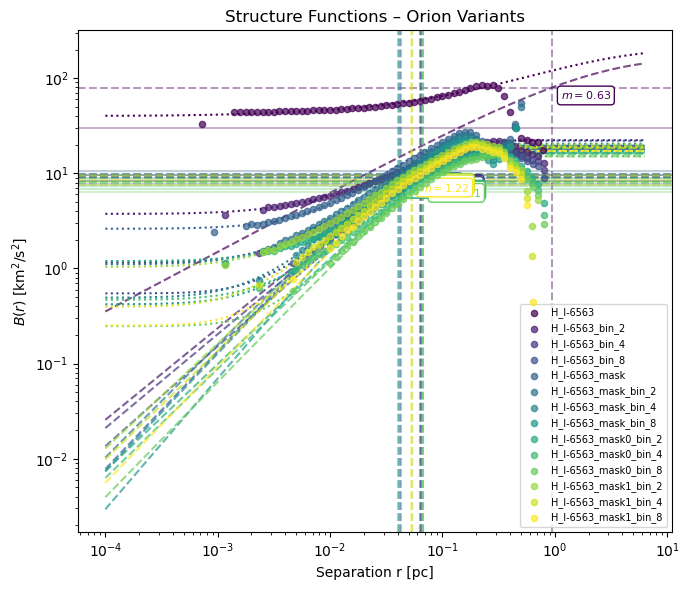

In [42]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 6))
rgrid = np.logspace(-4, 0.8)

for i, name in enumerate(data_in):
    d = data[name]
    color = colors[i]

    ax.axhline(d['sig2'], ls='--', color=color, alpha=0.4)
    ax.axvline(d['r0'], ls='--', color=color, alpha=0.4)

    ax.scatter(d['r'], d['B'], label=name, color=color, zorder=10, alpha=0.7, s=20)

    ax.plot(rgrid, bfunc.bfunc03s(rgrid, d['r0'], d['sig2'], d['m'], d['s0'], d['noise']), color=color, ls=':')
    ax.plot(rgrid, bfunc.bfunc00s(rgrid, d['r0'], d['sig2'], d['m']), color=color, ls='--', alpha=0.7)

    if 'sig2_' in d:
        ax.axhline(d['sig2_'], ls='-', color=color, alpha=0.3)

    # Annotate m
    ax.text(
        d['r0'] * 1.2, d['sig2'] * 0.75,
        f"$m = {d['m']:.2f}$", color=color,
        fontsize=8, bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3')
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Separation r [pc]')
ax.set_ylabel(r'$B(r)$ [km$^2$/s$^2$]')
ax.set_title('Structure Functions – Orion Variants')
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
#plt.savefig('figures/orion_structure_functions_variants.png', dpi=300)
plt.show()


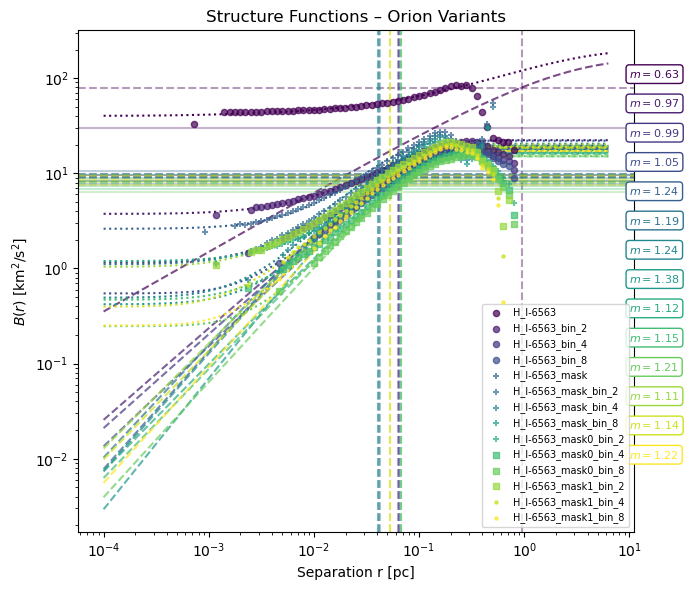

In [53]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 6))
rgrid = np.logspace(-4, 0.8)

for i, name in enumerate(data_in):
    d = data[name]
    color = colors[i]
    marker = markers[i % len(markers)]

    ax.axhline(d['sig2'], ls='--', color=color, alpha=0.4)
    ax.axvline(d['r0'], ls='--', color=color, alpha=0.4)

    ax.scatter(d['r'], d['B'], label=name, color=color, zorder=10, alpha=0.7, s=20, marker=marker)

    ax.plot(rgrid, bfunc.bfunc03s(rgrid, d['r0'], d['sig2'], d['m'], d['s0'], d['noise']), color=color, ls=':')
    ax.plot(rgrid, bfunc.bfunc00s(rgrid, d['r0'], d['sig2'], d['m']), color=color, ls='--', alpha=0.7)

    if 'sig2_' in d:
        ax.axhline(d['sig2_'], ls='-', color=color, alpha=0.3)

    # Annotate m
    x_annot, y_annot = annotation_coords[name]
    ax.text(
        x_annot, y_annot, f"$m = {d['m']:.2f}$", color=color,
        fontsize=8, bbox=dict(facecolor='white', edgecolor=color, boxstyle='round,pad=0.3')
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Separation r [pc]')
ax.set_ylabel(r'$B(r)$ [km$^2$/s$^2$]')
ax.set_title('Structure Functions – Orion Variants')
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig('orion_structure_functions_variants.png', dpi=300)
plt.show()
